<a href="https://colab.research.google.com/github/heejulie/LLM_Persona-AI-Agent/blob/main/02_only_pic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# only_pic — 이미지만

**구조** — ResNet18(ImageNet 사전학습) → GAP → 512

리뷰가 helpful 투표를 1개 이상 받을지 예측한다(이진 분류).
설계 문서: `docs/리뷰 Helpful 예측 — 딥러닝 모델 설계.md`

## 데이터 규약

| 단계 | 건수 | 역할 |
| --- | ---: | --- |
| 최종 EDA | 111,289건 | 전체 리뷰 |
| 리뷰 5~20개인 상품만 남김 | 42,779건 | **이 실험이 다루는 범위** |
| Train | 25,774건 | 학습 |
| Validation | 8,267건 | **설정 선택** |
| Test | 8,738건 | **마지막에 한 번 · 절대 학습 금지** |

이 노트북은 **validation까지만** 본다. test는 맨 아래 잠금 구역에 있고,
기본값으로는 파일조차 열지 않는다. 세 모델의 설정을 모두 확정한 뒤에
한 번만 연다. (왜 그래야 하는지는 다음 섹션에 있다.)

**예상 학습 시간(T4)**: 40~80분

---
### 실행 전
런타임 → 런타임 유형 변경 → **T4 GPU**


## 이게 뭘 하는 건가 — 3분 설명

아마존 패션 리뷰를 보고 **"이 리뷰가 다른 사람들에게 '도움이 됐어요' 투표를**
**받을까?"** 를 맞히는 프로그램을 만든다. 받으면 1, 못 받으면 0인 O/X 문제다.

그런데 우리가 진짜 궁금한 건 점수 자체가 아니라 이것이다.

> 리뷰의 **글**만 볼 때, **사진**만 볼 때, **둘 다** 볼 때
> — 어느 쪽이 더 잘 맞히나?

그래서 똑같은 리뷰들을 놓고 세 가지 프로그램을 따로 만들어 비교한다.
노트북이 3개인 이유가 이것이고, 이 노트북은 그중 하나를 맡는다.

### 컴퓨터가 어떻게 '맞히게' 되나

컴퓨터는 글자나 사진을 그대로 이해하지 못한다. 그래서 두 단계를 거친다.

1. **숫자로 바꾼다.** 단어 하나를 300개짜리 숫자 목록으로, 사진 한 장을
   픽셀 값 덩어리로 바꾼다.
2. **숫자를 조금씩 고친다.** 처음엔 엉터리로 찍는다. 정답과 얼마나 틀렸는지
   재고(이 값을 **loss**라고 한다), 틀린 만큼 프로그램 내부의 숫자 수백만 개를
   아주 조금씩 조정한다. 이걸 수만 번 반복하는 것이 **학습**이다.

이 노트북을 위에서부터 실행하면 그 과정이 자동으로 돌아가고, 마지막에
"얼마나 잘 맞히는지" 점수가 나온다.

### 왜 데이터를 세 덩어리로 나누나

시험 문제를 미리 보고 공부하면 시험 점수는 잘 나오지만 실력은 알 수 없다.
위 표의 세 덩어리가 정확히 그 이유로 나뉘어 있다.

- **Train**은 교과서다. 프로그램이 보고 배우는 데이터.
- **Validation**은 모의고사다. "이 설정이 나은가 저 설정이 나은가"를
  이리저리 바꿔 보며 고르는 데 쓴다. 여러 번 봐도 된다.
- **Test**는 실제 시험이다. **마지막에 딱 한 번**만 보고, 그 전엔 열지도 않는다.

test를 보면서 설정을 고치면 그건 시험 문제를 미리 본 것과 같다. 점수는
올라가지만 "처음 보는 리뷰에도 통하는가"를 더 이상 말할 수 없게 된다.
그래서 이 노트북의 코드는 **test를 아예 열지 않도록** 만들어져 있고,
맨 아래 🔒 잠금 구역에서만 연다.


## 처음 보는 용어

아래 설명에 나오는 말들이다. 지금 다 외울 필요는 없고, 막히면 여기로 돌아오면 된다.

**학습 과정에 관한 말**

| 용어 | 뜻 |
| --- | --- |
| loss (손실) | 정답에서 얼마나 벗어났는지를 잰 숫자. 작을수록 좋다 |
| epoch | 학습 데이터 전체를 한 번 훑는 것. 20 epoch = 25,774건을 20바퀴 |
| batch | 한 번에 묶어서 처리하는 개수. 여기선 32건씩 |
| 학습률 (learning rate) | 한 번에 얼마나 크게 고칠지. 크면 헤매고, 작으면 느리다 |
| gradient | "이 숫자를 어느 쪽으로 고쳐야 loss가 줄어드는지"를 알려주는 방향 |
| 과적합 (overfitting) | 교과서는 외웠는데 모의고사는 못 푸는 상태 |
| dropout | 학습 중에 일부러 일부를 끄는 것. 한 곳에 의존하지 못하게 해 과적합을 막는다 |
| early stopping | 모의고사 성적이 더 이상 안 오르면 학습을 일찍 멈추는 것 |

**모델 구조에 관한 말**

| 용어 | 뜻 |
| --- | --- |
| 사전학습 (pretrained) | 남이 이미 대규모 데이터로 학습해 둔 것을 가져다 쓰는 것 |
| 동결 (freeze) / 해동 | 가져온 부분을 잠시 고정해 두는 것 / 다시 학습되게 푸는 것 |
| 임베딩 (embedding) | 단어 하나를 숫자 300개로 바꾼 표현. 뜻이 비슷한 단어는 숫자도 비슷해진다 |
| 토큰 (token) | 문장을 쪼갠 조각. 대략 단어 하나 |
| GRU | 문장을 앞에서부터 순서대로 읽으며 기억을 갱신하는 부품 |
| Attention | 어느 단어를 얼마나 중요하게 볼지 가중치를 매겨 합치는 부품 |
| CNN / ResNet | 이미지에서 모서리·질감·모양 같은 특징을 뽑아내는 부품 |
| logit → sigmoid | 모델이 뱉은 날숫자를 0~1 사이 확률로 눌러 주는 변환 |
| threshold (임계값) | "확률이 얼마 이상이면 1로 볼까"의 기준선. 보통 0.5 |

> 여기부터 몇 섹션은 조금 기술적이다. **결과만 보고 싶다면 "데이터 점검"까지
> 실행한 뒤 "Validation 결과" 섹션으로 건너뛰어도 된다.**


## 이 모델의 구조

```
리뷰 이미지 URL
  ↓ 다운로드 · 긴 변 256으로 축소 저장
  ↓ letterbox 224×224 (비율 유지 + 여백 채움)
  ↓ ImageNet 정규화
[B, 3, 224, 224]
  ↓ ResNet18 (ImageNet 사전학습, 마지막 fc 제거)
[B, 512]                Global Average Pooling 출력
  ↓ Projection(512→128) + ReLU + Dropout(0.2)
[B, 128]
  ↓ MLP(128 → 64 → 1)
[B, 1]                  logit → sigmoid → 확률
```

**왜 ResNet18인가.** 42,779건은 CNN을 처음부터 학습시키기에 넉넉한 양이 아니다.
ImageNet으로 학습된 저수준 특징(모서리·질감·색 패턴)을 가져오면 적은 데이터로도
출발점이 좋다. 더 깊은 ResNet50은 파라미터가 2배 이상이라 이 규모에서는 과적합
위험과 학습시간이 함께 늘어난다.

**왜 fc를 떼는가.** 원래 fc는 ImageNet 1000개 클래스용이다. 우리가 필요한 것은
그 앞 단계인 GAP 출력 512차원 표현이므로, fc를 Identity로 바꿔 512를 그대로 받는다.

> `B`는 batch(32), `L`은 그 batch에서 가장 긴 리뷰의 토큰 수다. 짧은 리뷰는
> PAD로 채우되, GRU가 PAD를 읽지 않도록 `pack_padded_sequence`를 쓰고
> Attention의 softmax 전에도 PAD를 마스킹한다. **이 둘은 서로 다른 단계이며**
> `B`는 batch(32)다. 모든 이미지는 224×224로 맞춰지므로 길이 문제가 없다.

### 이미지 전처리에서 정한 값들

- **letterbox 224×224** — 비율을 유지한 채 줄이고 남는 곳을 채운다. CenterCrop을
  쓰면 옷의 일부가 잘려 판단 근거가 사라질 수 있다. 대신 여백이 생기고 물체가
  상대적으로 작아지는 대가가 있다(§4.2 ④).
- **여백은 ImageNet 평균색으로 채운다** — 정규화를 거치면 그 픽셀이 0이 되어,
  합성곱이 여백을 '밝은 영역'으로 읽지 않는다. 흰색으로 채우면 정규화 후 +2 부근의
  큰 값이 되어 여백이 오히려 강한 신호가 된다.
- **정규화 상수는 ImageNet 값으로 고정** (`mean=[0.485,0.456,0.406]`,
  `std=[0.229,0.224,0.225]`) — train에서 새로 추정하면 사전학습 ResNet이 전제한
  입력 분포와 어긋난다. 외부 고정 상수를 쓰는 것은 split을 미리 보는 것이 아니므로
  누출이 아니다(§6.2).
- **증강은 좌우 반전만** (train에만, p=0.5) — '이 리뷰가 유용한가'라는 라벨을 바꾸지
  않는 범위로 제한했다. 강한 crop이나 색상 변형은 옷의 형태·색을 바꾸므로 제외했다.


## 1. GPU 확인


In [7]:
import importlib.util
import subprocess
import sys
# 현재 노트북 커널에 PyTorch 설치 (cu121 전용 저장소를 강제하지 않음)
if importlib.util.find_spec('torch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch', 'torchvision'])
import torch
import torchvision
gpu = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True,
    text=True).stdout.strip()
print(gpu or 'NVIDIA GPU 정보를 찾지 못함')
print('torch', torch.__version__, '| CUDA:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'GPU가 아니다. 런타임 유형을 T4 GPU로 바꿔라.'

Tesla T4, 15360 MiB
torch 2.11.0+cu128 | CUDA: True


## 2. Drive 연결

GloVe·이미지·결과를 Drive에 두면 런타임이 끊겨도 다시 받지 않는다.
세 노트북이 같은 폴더를 공유한다.


In [8]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
DRIVE = Path('/content/drive/MyDrive/dl_helpful')   # 세 노트북 공통
DRIVE.mkdir(parents=True, exist_ok=True)
OUTPUTS = DRIVE / 'outputs'
print('공유 폴더:', DRIVE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
공유 폴더: /content/drive/MyDrive/dl_helpful


## 3. 코드와 데이터

`project_bundle.zip`과 parquet 3개를 올린다. 한 번 올리면 Drive에 남아
다음 노트북·다음 세션에서는 이 셀이 자동으로 건너뛴다.


In [12]:
import shutil, zipfile

WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
DATA = Path('/content/data');  DATA.mkdir(exist_ok=True)
PARQUETS = [f'fashion_ranking_5to20_{x}.parquet' for x in ('train', 'validation', 'test')]

missing = [f for f in ['project_bundle.zip'] + PARQUETS if not (DRIVE / f).exists()]
if missing:
    print('업로드가 필요한 파일:', missing)
    from google.colab import files
    for name in files.upload():
        shutil.move(name, DRIVE / name)
else:
    print('Drive에 모두 있음 — 업로드 불필요')

with zipfile.ZipFile(DRIVE / 'project_bundle.zip') as zf:
    zf.extractall(WORK)
for f in PARQUETS:
    if not (DATA / f).exists():
        shutil.copy(DRIVE / f, DATA / f)

%cd /content/work
!ls


업로드가 필요한 파일: ['fashion_ranking_5to20_train.parquet', 'fashion_ranking_5to20_validation.parquet', 'fashion_ranking_5to20_test.parquet']


Saving fashion_ranking_5to20_test.parquet to fashion_ranking_5to20_test.parquet
Saving fashion_ranking_5to20_train.parquet to fashion_ranking_5to20_train.parquet
Saving fashion_ranking_5to20_validation.parquet to fashion_ranking_5to20_validation.parquet
Saving project_bundle.zip to project_bundle.zip
/content/work
docs  notebooks  README.md  requirements.txt  scripts  src  train.py


## 4. 환경 준비

torch·torchvision은 Colab에 이미 있다. NLTK 토크나이저 데이터와,
그래프에 한글을 쓰기 위한 폰트만 설치한다.


In [13]:
!pip install -q nltk
import nltk
nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
print(word_tokenize('tokenizer works.'))


['tokenizer', 'works', '.']


In [14]:
# 그래프 한글 깨짐 방지 (Colab에는 한글 폰트가 없다)
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1
import matplotlib as mpl, matplotlib.font_manager as fm

FONT = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if Path(FONT).exists():
    fm.fontManager.addfont(FONT)
    mpl.rc('font', family=fm.FontProperties(fname=FONT).get_name())
    print('한글 폰트 적용:', mpl.rcParams['font.family'])
else:
    print('한글 폰트 설치 실패 — 그래프 라벨이 네모로 보일 수 있다(결과에는 영향 없음)')
mpl.rc('axes', unicode_minus=False)   # 마이너스 기호 깨짐 방지


한글 폰트 적용: ['NanumGothic']


## 5. 데이터 점검

건수·양성비율·split 누출을 확인하고, 위 표의 숫자와 일치하는지 검증한다.


In [15]:
!python scripts/check_data.py --data-dir /content/data


1) split 기본 통계
  train        25,774건  parent_asin 3,485개  양성 61.38%  본문공백 1,148건
  validation    8,267건  parent_asin 1,140개  양성 61.38%  본문공백   385건
  test          8,738건  parent_asin 1,184개  양성 61.92%  본문공백   421건
  합계           42,779건

2) 누출 점검 (split 사이 교집합)
  train∩validation   parent_asin    0  review_id    0  image_url    8  user_id  308
  train∩test         parent_asin    0  review_id    0  image_url   11  user_id  328
  validation∩test    parent_asin    0  review_id    0  image_url    4  user_id   93
  → parent_asin 교집합이 0이어야 '새로운 상품 일반화' 조건이 성립한다.

3) 이미지 확보 상태
  image_url 결측 0건 · 빈 문자열 0건 (train)
  URL만 있으므로 scripts/download_images.py로 로컬에 받아야 한다.

4) 토큰 길이 (train 표본 4,000건, 소문자화 기준)
  평균 44.5 · 중앙값 35 · p90 93 · p95 117 · p99 171 · 최대 412
  max_len 후보별 잘림 비율 / 토큰 보존율
      96:  8.88% / 92.87%
     128:  3.15% / 97.07% ←기준
     160:  1.45% / 98.57%
     192:  0.60% / 99.24%
     256:  0.18% / 99.73%

5) 확인 필요
  product_review_count 범위: 5 ~ 20
  EDA 문서는 인기도 cutoff를 20~100, 최

In [16]:
import pandas as pd

EXPECTED = {'train': 25774, 'validation': 8267, 'test': 8738}
for split, n in EXPECTED.items():
    got = len(pd.read_parquet(f'/content/data/fashion_ranking_5to20_{split}.parquet'))
    assert got == n, f'{split}: {got:,}건 — 기대 {n:,}건과 다르다'
    print(f'{split:<11} {got:>7,}건  ✓')
print(f'합계 42,779건  ✓')


train        25,774건  ✓
validation    8,267건  ✓
test          8,738건  ✓
합계 42,779건  ✓


## 6. 구현 점검

동결/해동, BatchNorm 통계 고정, PAD 마스킹 등 16개 항목.


In [17]:
!python scripts/selftest.py


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 105MB/s]

1) 동결 구간 (epoch 0 < freeze_epochs)
  [PASS] Embedding requires_grad=False
  [PASS] ResNet backbone이 eval 모드 (BN 통계 고정)
  [PASS] Embedding 값이 변하지 않음
  [PASS] BN running_mean이 변하지 않음
  [PASS] BiGRU는 동결 구간에도 학습됨
  [PASS] 사전학습 그룹 lr=0
  [PASS] 사전학습 그룹 weight_decay=0 (동결 중 값 이동 방지)

2) 해동 구간 (epoch 2 >= freeze_epochs)
  [PASS] Embedding requires_grad=True
  [PASS] ResNet backbone이 train 모드
  [PASS] Embedding 값이 갱신됨
  [PASS] BN running_mean이 갱신됨
  [PASS] 사전학습 그룹 lr = head lr × 0.1 (1.0e-04)

3) 평가 모드
  [PASS] eval에서 두 번 호출 결과 동일 (Dropout off)

4) PAD 처리
  [PASS] PAD를 덧붙여도 logit이 같음 (pack + attention 마스킹)

5) 단일 모달리티 모델
  [PASS] text-only 출력 shape (4,) == (B,) 1 logit
  [PASS] image-only 출력 shape (4,) == (B,) 1 logit

전체 16개 항목 통과


## 7. 이미지 42,779장

가장 오래 걸리는 단계(25~50분). 받은 뒤 Drive에 tar로 보관하므로
다음 세션과 다른 노트북에서는 복원만 한다. 중단돼도 다시 실행하면 이어받는다.

리뷰 42,779건은 모두 image_url을 갖고 있지만, 다운로드가 실패하는 건이 일부 생긴다. 그 리뷰는 **세 모델 모두에서 똑같이 빠져야** 비교가 성립한다.


In [18]:
import tarfile

IMAGES = Path('/content/data/images'); IMAGES.mkdir(parents=True, exist_ok=True)
MANIFEST = Path('/content/data/images_manifest.csv')
TAR = DRIVE / 'images.tar'

if TAR.exists() and not any(IMAGES.glob('*.jpg')):
    print('Drive 캐시에서 복원 중... (수 분 소요)')
    with tarfile.open(TAR) as tf:
        tf.extractall('/content/data')
    if (DRIVE / 'images_manifest.csv').exists():
        shutil.copy(DRIVE / 'images_manifest.csv', MANIFEST)
print('보유:', len(list(IMAGES.glob('*.jpg'))), '장')


보유: 0 장


In [19]:
# 먼저 200장으로 확인 (2~3분)
!python scripts/download_images.py --data-dir /content/data \
    --out-dir /content/data/images --manifest /content/data/images_manifest.csv \
    --workers 16 --limit 200


대상 600건 · 저장 위치 /content/data/images · workers 16
downloading: 100% 600/600 [00:17<00:00, 34.92it/s]

이번 실행 결과:
  ok             600
  성공률 100.00%

manifest: /content/data/images_manifest.csv
  기존 0행 + 이번 600건 → 누적 600행
  이미지 확보 누적 600건 (100.00%)


In [20]:
# 전체 다운로드. 위 테스트가 성공했을 때만 실행한다 (25~50분)
!python scripts/download_images.py --data-dir /content/data \
    --out-dir /content/data/images --manifest /content/data/images_manifest.csv \
    --workers 16


대상 42,779건 · 저장 위치 /content/data/images · workers 16
downloading: 100% 42779/42779 [19:16<00:00, 36.98it/s]

이번 실행 결과:
  ok             42,179
  cached         600
  성공률 100.00%

manifest: /content/data/images_manifest.csv
  기존 600행 + 이번 42,779건 → 누적 42,779행
  이미지 확보 누적 42,779건 (100.00%)


In [21]:
# Drive에 보관 — 다른 노트북과 다음 세션이 이걸 쓴다
n = len(list(IMAGES.glob('*.jpg')))
print(n, '장 보관 중... (수 분 소요)')
with tarfile.open('/content/images.tar', 'w') as tf:
    tf.add(IMAGES, arcname='images')
shutil.copy('/content/images.tar', DRIVE / 'images.tar')
shutil.copy(MANIFEST, DRIVE / 'images_manifest.csv')
print('Drive 저장 완료 —', DRIVE)


42779 장 보관 중... (수 분 소요)
Drive 저장 완료 — /content/drive/MyDrive/dl_helpful


## 8. 학습

| 설정 | 값 |
| --- | --- |
| optimizer | Adam |
| batch size | 32 |
| 학습률(head) | 1e-3 |
| dropout | 0.2 |
| weight decay | 0.0 |
| gradient clipping | 1.0 |
| 동결 구간 | 2 epoch |
| 해동 후 사전학습 학습률 | 1e-3 × 0.1 |
| epoch 상한 | 20 |
| early stopping | patience 4 (validation BCE) |

이 값들은 설계 문서 §6.3의 **탐색 출발점**이지 최적값이 아니다.
최종 선택은 validation으로 한다.

### 왜 처음 2 epoch은 사전학습 가중치를 얼리는가

학습 시작 시점에 Projection과 Head는 랜덤 초기화 상태다. 여기서 나오는 loss는
크고, 그 gradient가 사전학습된 Embedding·ResNet까지 그대로 흘러간다. GloVe와
ImageNet이 대규모 데이터로 얻은 표현이 **첫 몇 step의 큰 gradient에 망가질 수**
**있다**(catastrophic forgetting). 그래서 순서를 나눈다.

| 구간 | epoch | 학습되는 것 | 사전학습 파라미터 |
| --- | --- | --- | --- |
| 1단계 | 0~1 | Projection · Head · BiGRU · Attention | 동결 (lr 0) |
| 2단계 | 2~ | 전부 | 해동, lr = head의 1/10 |

**동결 대상은 '인코더 전체'가 아니라 '사전학습된 값을 가진 부분'이다.**
BiGRU와 Attention은 랜덤 초기화이므로 1단계에서도 학습해야 한다. 이걸 같이
얼리면 1단계가 사실상 낭비된다.

**두 가지 함정** — 둘 다 빠뜨려도 코드는 조용히 돌아간다. `selftest.py`가 검사한다.

1. `requires_grad=False`만으로는 ResNet의 **BatchNorm이 running statistics를**
   **계속 갱신한다.** 동결 구간에는 backbone을 `.eval()`로 둬야 한다.
2. optimizer에 사전학습 파라미터를 넣어 둔 채 weight decay를 걸면 **gradient가**
   **0이어도 값이 움직인다.** 동결 구간에는 그 그룹의 `lr`과 `weight_decay`를
   둘 다 0으로 둔다.

### early stopping이 세는 방식

patience는 **해동 이후부터** 센다. 동결 구간과 fine-tune 구간은 학습 조건이
다르므로 함께 세면 조기 종료가 잘못 걸린다. 다만 **best 체크포인트는 동결
구간까지 포함해** validation BCE가 가장 낮은 epoch을 고른다. 그래서 해동 후
성능이 나빠지면 동결 구간의 체크포인트가 선택될 수도 있다 — 그 경우
`selected_epoch`이 2보다 작게 나온다.

### test는 열지 않는다

아래 셀에 `--eval-test`가 없다. test는 Dataset으로도 만들어지지 않으며,
토큰화조차 되지 않는다.


In [ ]:
RUN = 'only_pic'
COMMON = f'--data-dir /content/data --output-dir {OUTPUTS} --num-workers 2'
print(COMMON)


In [23]:
!python train.py --modality image --image-dir /content/data/images \
    {COMMON} --run-name {RUN}



=== IMAGE · run=only_pic · device=cuda ===
· train       25,774건  양성 61.38%
· validation   8,267건  양성 61.38%
· test         8,738건  양성 61.92%
· 파라미터 전체 11,250,497 | 동결 구간 학습 대상 73,985 → 해동 후 11,250,497
  epoch  0 [  frozen] train_loss=0.6680  val_bce=0.6501 val_auroc=0.6075 (73s)  ← best
  epoch  1 [  frozen] train_loss=0.6570  val_bce=0.6491 val_auroc=0.6111 (70s)  ← best
  epoch  2 [finetune] train_loss=0.6586  val_bce=0.6563 val_auroc=0.6051 (97s)
  epoch  3 [finetune] train_loss=0.6505  val_bce=0.6566 val_auroc=0.5915 (102s)
  epoch  4 [finetune] train_loss=0.6353  val_bce=0.6536 val_auroc=0.6055 (102s)
  epoch  5 [finetune] train_loss=0.6015  val_bce=0.6736 val_auroc=0.5874 (102s)
  early stopping (patience 4 소진, best epoch 1)
· best epoch 1 체크포인트로 평가
  validation threshold=0.45 (F1 0.7612)
  validation  bce=0.6491  auroc=0.6111  ap=0.6925  f1=0.7612  precision=0.6158  recall=0.9965  accuracy=0.6162
  test        건너뜀 (--eval-test 미지정 — 설정 확정 후 한 번만 실행)

저장 위치: /content/drive/MyDr

## 9. Validation 결과

이 모델의 설정 선택 근거다. test는 여기 없다.

### 지표를 어떻게 읽는가

**먼저 함정 하나.** 이 데이터는 61.4%가 '투표를 받은 리뷰'다. 그래서
**아무것도 배우지 않고 전부 1로만 찍어도 정답률(accuracy) 61.4%가 나온다.**
정답률이 61%라고 좋아하면 안 되는 이유다.

그래서 주로 보는 건 **AUROC**다. 뜻은 이렇다.

> 투표를 **받은** 리뷰 하나와 **못 받은** 리뷰 하나를 무작위로 집어 든다.
> 모델이 앞쪽에 더 높은 점수를 줄 **확률**이 AUROC다.

- 0.5 = 동전 던지기와 같음 (아무 실력 없음)
- 1.0 = 항상 맞게 순서를 매김 (완벽)
- 0.5보다 **낮으면** 오히려 거꾸로 맞히고 있다는 뜻이다

AUROC는 임계값(threshold)을 어디에 두든 변하지 않는다. 그래서 세 모델을
비교할 때 가장 먼저 볼 숫자다.

| 지표 | 무엇을 보는가 | threshold 영향 |
| --- | --- | --- |
| BCE | 확률값 자체의 품질. 틀린 쪽에 확신할수록 크게 벌점 | 없음 |
| AUROC | 양성을 음성보다 높게 매기는 순위 능력. 0.5 = 무작위 | 없음 |
| AP | precision–recall 곡선 아래 면적. 양성비율(0.614)이 baseline | 없음 |
| F1 · Precision · Recall · Accuracy | 특정 threshold로 자른 뒤의 성능 | 있음 |

**선택은 BCE로, threshold는 F1으로 — 순서가 있다.**

1. 어느 epoch의 체크포인트를 쓸지는 **validation BCE 최소**로 정한다.
   threshold와 무관하게 확률 자체의 품질을 보기 때문이다.
2. 고른 체크포인트에 대해, validation에서 **F1이 최대가 되는 threshold**를 찾는다.
3. test에서는 이 threshold를 **다시 조정하지 않는다.** 조정하면 test가 설정
   선택에 관여하게 되어 out-of-sample이 아니게 된다(§7.2).

AUROC와 AP는 threshold와 무관하므로, 모달리티 비교에서 가장 먼저 볼 지표다.


In [ ]:
import json

m = json.load(open(OUTPUTS / RUN / 'metrics.json'))
v = m['validation_metrics']

print(f"=== {RUN} ({m['modality']}) ===")
print(f"  validation 건수   : {m['data']['validation']['rows_after']:,}건")
print(f"  선택된 epoch      : {m['selected_epoch']} (총 {m['epochs_run']} epoch 실행)")
print(f"  선택 기준         : validation BCE {m['validation_selection_metric']['value']:.4f}")
print(f"  threshold         : {v['threshold']:.2f}  (validation F1 최대점)")
print()
print(f"  AUROC             : {v['auroc']:.4f}   threshold와 무관한 순위 성능")
print(f"  Average Precision : {v['ap']:.4f}")
print(f"  F1                : {v['f1']:.4f}")
print(f"  Precision         : {v['precision']:.4f}")
print(f"  Recall            : {v['recall']:.4f}")
print(f"  Accuracy          : {v['accuracy']:.4f}")
print(f"  BCE               : {v['bce']:.4f}")
print()
print(f"  실제 양성비율     : {v['positive_rate_true']:.2%}")
print(f"  예측 양성비율     : {v['positive_rate_pred']:.2%}")
print(f"  학습 파라미터     : {m['parameters']['finetune_phase']['trainable']:,}")
print(f"  총 학습 시간      : {m['total_train_seconds']:,.0f}초")
if m['glove'].get('pretrained'):
    print(f"  GloVe 커버리지    : type {m['glove']['coverage_type']:.1%},"
          f" token {m['glove']['coverage_token']:.1%}")
print()
if m['test_evaluated']:
    print('  test          : 이미 평가됨 (잠금 구역을 실행한 뒤다)')
else:
    print('  test          : 아직 열지 않음 ✓  ← 설정 선택 단계에서는 이게 정상')


### 항상 양성으로 찍는 것보다 나은가

양성비율이 61.4%라 accuracy 0.614는 아무것도 배우지 않아도 나온다.
AUROC가 0.5를 의미 있게 넘는지가 실제 기준이다.


In [ ]:
base_acc = v['positive_rate_true']
print(f"전부 양성으로 찍을 때 accuracy : {base_acc:.4f}")
print(f"이 모델의 accuracy             : {v['accuracy']:.4f}  ({v['accuracy'] - base_acc:+.4f})")
print(f"이 모델의 AUROC                : {v['auroc']:.4f}  (무작위 = 0.5)")


### 이 결과를 말로 옮기면

숫자를 그대로 읽는 대신, 아래 셀이 문장으로 바꿔 준다.
발표나 보고서에 쓸 때 이 표현을 그대로 쓰면 된다.


In [26]:
auroc = v['auroc']

print(f'■ {RUN} — validation {m["data"]["validation"]["rows_after"]:,}건 기준')
print()
print(f'  AUROC {auroc:.3f} 라는 것은:')
print(f'    투표를 받은 리뷰 하나와 못 받은 리뷰 하나를 무작위로 뽑았을 때,')
print(f'    모델이 "받은 쪽"에 더 높은 점수를 줄 확률이 {auroc:.1%} 라는 뜻이다.')
print(f'    (동전 던지기 = 50.0%, 완벽 = 100.0%)')
print()

# 아래 구간은 관례적인 눈금일 뿐 정해진 규칙이 아니다. 해석의 출발점으로만 쓴다.
if auroc >= 0.70:
    verdict = '뚜렷한 신호가 있다'
elif auroc >= 0.60:
    verdict = '약하지만 분명한 신호가 있다'
elif auroc >= 0.55:
    verdict = '신호가 미약하다'
elif auroc > 0.50:
    verdict = '무작위와 큰 차이가 없다'
else:
    verdict = '무작위보다 못하다 — 파이프라인을 의심해 볼 것'
print(f'  판정: {verdict}')
print()
print(f'  정답률로 보면 {v["accuracy"]:.1%} 인데, 전부 1로만 찍어도',
      f'{base_acc:.1%} 가 나오므로')
print(f'  실제로 벌어들인 차이는 {v["accuracy"] - base_acc:+.1%} 다.')
print()
print(f'  이 모델은 100개 중 {v["positive_rate_pred"] * 100:.0f}개를 "투표받을 것"으로 예측했고,')
print(f'  그중 실제로 맞은 비율(precision)이 {v["precision"]:.1%},')
print(f'  실제 투표받은 리뷰 가운데 찾아낸 비율(recall)이 {v["recall"]:.1%} 다.')


■ only_pic — validation 8,267건 기준

  AUROC 0.611 라는 것은:
    투표를 받은 리뷰 하나와 못 받은 리뷰 하나를 무작위로 뽑았을 때,
    모델이 "받은 쪽"에 더 높은 점수를 줄 확률이 61.1% 라는 뜻이다.
    (동전 던지기 = 50.0%, 완벽 = 100.0%)

  판정: 약하지만 분명한 신호가 있다

  정답률로 보면 61.6% 인데, 전부 1로만 찍어도 61.4% 가 나오므로
  실제로 벌어들인 차이는 +0.2% 다.

  이 모델은 100개 중 99개를 "투표받을 것"으로 예측했고,
  그중 실제로 맞은 비율(precision)이 61.6%,
  실제 투표받은 리뷰 가운데 찾아낸 비율(recall)이 99.6% 다.


### 학습 곡선

train loss와 validation BCE가 벌어지는 지점이 과적합이 시작되는 곳이다.
세로 점선이 사전학습 가중치를 푼 시점(해동), 빨간 원이 선택된 epoch이다.

**곡선에서 무엇을 봐야 하는가**

| 보이는 현상 | 해석 | 대응 |
| --- | --- | --- |
| train loss ↓, val BCE ↑ | 과적합 | dropout 0.4 / weight decay 1e-4. early stopping이 이미 이른 epoch을 고른다 |
| 둘 다 거의 안 내려감 | 학습률 문제 | `--lr 3e-4` 또는 `--lr 3e-3` 시도 |
| 해동 직후 loss가 크게 튐 | 사전학습 학습률이 큼 | `--encoder-lr-mult 0.05` |
| 해동 직후 개선이 전혀 없음 | 동결 구간이 짧거나 김 | `--freeze-epochs 1` 또는 `3` |
| AUROC가 0.5 근처에서 안 움직임 | 신호가 거의 없거나 파이프라인 문제 | selftest·데이터 점검부터 다시 |

마지막 항목은 특히 주의해서 보라. **이 모달리티에 예측 신호가 거의 없다는
결과 자체도 유효한 발견이다.** 억지로 성능을 올리려 하기 전에, 그 가능성을
먼저 검토하는 편이 정직하다.


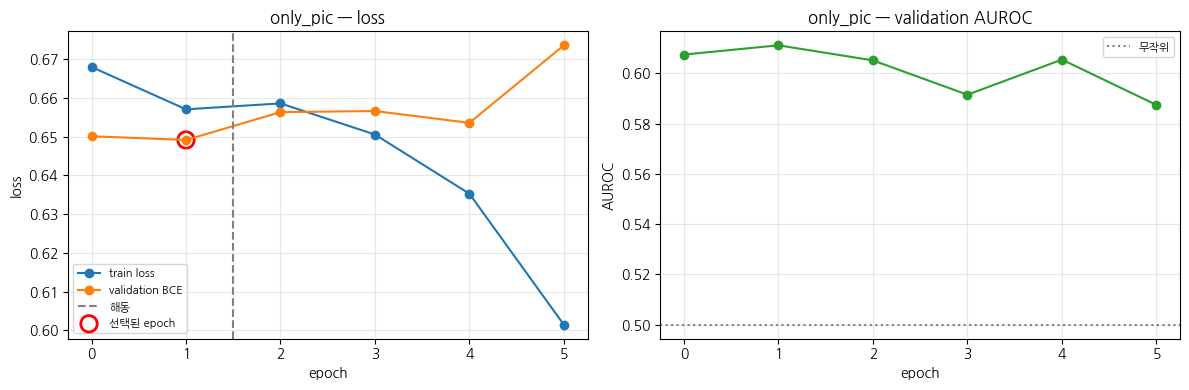

,epoch,phase,train_loss,epoch_seconds,val_bce,val_auroc,val_ap,val_f1,val_precision,val_recall,val_accuracy,val_threshold,val_positive_rate_true,val_positive_rate_pred
0,0,frozen,0.667963,73.2,0.650098,0.607463,0.687879,0.749585,0.647008,0.890816,0.634692,0.5,0.613766,0.845047
1,1,frozen,0.657038,70.0,0.649129,0.611140,0.692464,0.755006,0.643095,0.914072,0.635902,0.5,0.613766,0.872384
2,2,finetune,0.658567,97.5,0.656314,0.605139,0.691051,0.758133,0.621642,0.971423,0.619572,0.5,0.613766,0.959115
3,3,finetune,0.650537,101.9,0.656600,0.591482,0.679978,0.760475,0.619846,0.983642,0.619693,0.5,0.613766,0.973993
4,4,finetune,0.635264,102.2,0.653552,0.605456,0.693164,0.736700,0.645281,0.858297,0.623443,0.5,0.613766,0.816378
5,5,finetune,0.601457,101.8,0.673557,0.587437,0.680730,0.698129,0.650230,0.753646,0.599976,0.5,0.613766,0.711383


In [27]:
import pandas as pd, matplotlib.pyplot as plt

log = pd.read_csv(OUTPUTS / RUN / 'train_log.csv')
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(log.epoch, log.train_loss, marker='o', label='train loss')
ax[0].plot(log.epoch, log.val_bce, marker='o', label='validation BCE')
unfreeze = log.loc[log.phase == 'finetune', 'epoch'].min()
if pd.notna(unfreeze):
    ax[0].axvline(unfreeze - 0.5, ls='--', c='gray', label='해동')
best = log.val_bce.idxmin()
ax[0].scatter([log.epoch[best]], [log.val_bce[best]], s=140,
              facecolors='none', edgecolors='red', lw=2, label='선택된 epoch')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].set_title(f'{RUN} — loss')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].plot(log.epoch, log.val_auroc, marker='o', c='tab:green')
ax[1].axhline(0.5, ls=':', c='gray', label='무작위')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('AUROC')
ax[1].set_title(f'{RUN} — validation AUROC')
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

log


### threshold를 어디에 두느냐에 따른 변화

모델이 내는 것은 확률이고, threshold는 그 뒤에 붙는 별도의 선택이다.


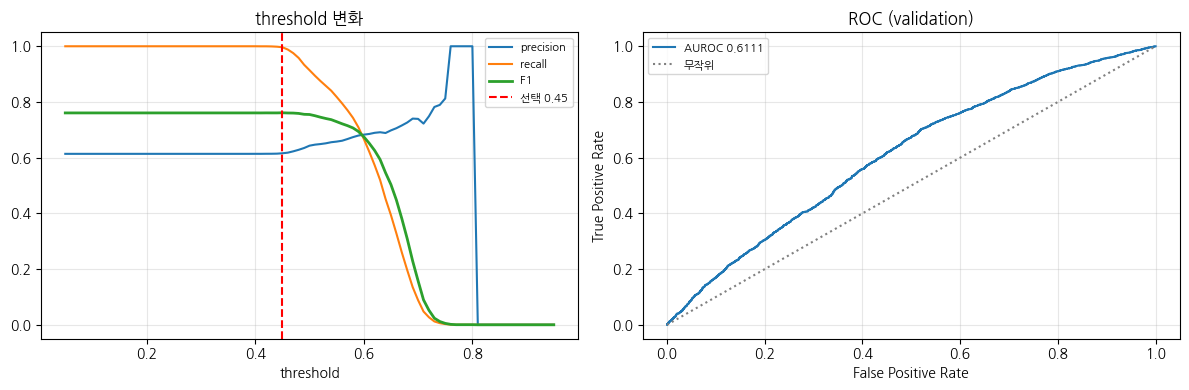

혼동행렬 (threshold 0.45)
              예측 0    예측 1
  실제 0         38     3,155
  실제 1         18     5,056


In [28]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, roc_curve, confusion_matrix

pred = pd.read_csv(OUTPUTS / RUN / 'predictions_validation.csv')
y, p = pred.y_true.values, pred.probability.values

grid = np.arange(0.05, 0.96, 0.01)
rows = [precision_recall_fscore_support(y, (p >= t).astype(int),
                                        average='binary', zero_division=0)[:3] for t in grid]
prec, rec, f1s = map(np.array, zip(*rows))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(grid, prec, label='precision')
ax[0].plot(grid, rec, label='recall')
ax[0].plot(grid, f1s, label='F1', lw=2)
ax[0].axvline(v['threshold'], ls='--', c='red', label=f"선택 {v['threshold']:.2f}")
ax[0].set_xlabel('threshold'); ax[0].set_title('threshold 변화');
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

fpr, tpr, _ = roc_curve(y, p)
ax[1].plot(fpr, tpr, label=f"AUROC {v['auroc']:.4f}")
ax[1].plot([0, 1], [0, 1], ls=':', c='gray', label='무작위')
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC (validation)'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

cm = confusion_matrix(y, (p >= v['threshold']).astype(int))
print(f"혼동행렬 (threshold {v['threshold']:.2f})")
print(f"              예측 0    예측 1")
print(f"  실제 0   {cm[0,0]:>8,} {cm[0,1]:>9,}")
print(f"  실제 1   {cm[1,0]:>8,} {cm[1,1]:>9,}")


## 10. 설정 탐색 (선택)

validation으로만 비교한다. `--tag`를 붙이면 run 폴더가 분리된다.
바꾼 설정은 `config.json`에 그대로 기록되므로 나중에 재현할 수 있다.


In [29]:
# 예: 학습률과 dropout을 바꿔 본다
# !python train.py --modality image --image-dir /content/data/images \
#     {COMMON} --lr 3e-4 --dropout 0.4 --tag lr3e-4_dr0.4


## 11. 세 모델 비교

나머지 두 노트북(01_only_text.ipynb, 03_text_pic.ipynb)을 돌린 뒤에 실행한다.
셋 다 없으면 있는 것만 나온다. 세 노트북이 같은 Drive 폴더에 결과를
쓰므로, 어느 노트북에서 실행해도 같은 표가 나온다.

**표를 믿어도 되는지 먼저 확인한다.** 세 모델이 서로 다른 리뷰를 봤다면
성능 차이가 모달리티 때문인지 데이터가 달라서인지 구분할 수 없다. 그래서
이 스크립트는 각 run의 `split_manifest.csv`에서 validation review_id를
읽어 **집합이 정확히 같은지** 대조한다. 건수만 비교하면 '120건 vs 120건인데
구성이 완전히 다른' 경우를 놓치기 때문이다.

출력 맨 아래가 이렇게 나와야 비교가 성립한다.

```
✓ validation 8,2XX건이 세 모델에서 **완전히 동일**하다
  → validation 결과만으로 모달리티를 비교해도 된다
```

⚠️ 로 시작하는 경고가 뜨면 Text-only를 `--image-manifest`로 다시 돌려야 한다.


In [30]:
!python scripts/compare_runs.py --output-dir {OUTPUTS} \
    --runs only_text only_pic text_pic --csv {OUTPUTS}/comparison.csv



■ VALIDATION 8,267건 — 설정 선택 기준
run                     모델               auroc        ap        f1 precision    recall  accuracy       bce
----------------------------------------------------------------------------------------------------------
only_pic                only_pic        0.6111    0.6925    0.7612    0.6158    0.9965    0.6162    0.6491

■ 선택 근거와 비용
run                      best epoch   val BCE  threshold        학습 파라미터      총 학습(초)
------------------------------------------------------------------------------------
only_pic                          1    0.6491       0.45     11,250,497          702

■ TEST 8,738건 — 아직 열지 않음
  설정을 validation으로 확정한 뒤 아래를 각 run에 대해 한 번만 실행한다.
    python scripts/eval_test.py --run <output_dir>/<run_name>

■ 비교 조건 점검 — 세 모델이 같은 리뷰를 봤는가
  비교할 run이 2개 미만이다
  seed: 42

  주의: 이 표는 seed 고정 1회 실행의 결과다. 순위의 안정성을 확인한 것이
  아니며, 사전학습 vs 랜덤 초기화 비교도 포함되어 있지 않다(설계 문서 §8).

저장: /content/drive/MyDrive/dl_helpful/outputs/comparison.csv


---
---
# 🔒 12. TEST 8,738건 — 잠금 구역

**세 모델의 설정을 모두 확정하기 전에는 실행하지 않는다.**

test를 보면서 설정을 고르면 test는 두 번째 validation이 되고,
out-of-sample 추정치라는 의미를 잃는다. 그래서 이 노트북의 학습 셀은
test를 아예 열지 않도록 되어 있다(`test_evaluated: False`).

### 실행 조건
1. 세 모델 모두 validation으로 설정을 확정했다
2. 더 이상 설정을 바꾸지 않는다
3. 이 셀은 **한 번만** 실행한다

### 재학습하지 않는다

`scripts/eval_test.py`는 위에서 저장된 `best.pt`를 **그대로 불러와** 평가한다.
`train.py --eval-test`로 처음부터 다시 학습하는 방법도 있지만 두 가지가 걸린다.

1. **비용** — Multimodal은 50~90분을 한 번 더 쓴다.
2. **재현성** — GPU 연산은 완전한 결정성을 보장하지 않는다(cuDNN의 비결정적
   커널, atomicAdd의 부동소수점 덧셈 순서). seed를 고정해도 재학습 결과가
   validation을 보고 고른 그 모델과 미세하게 다를 수 있다. 그러면 "내가 검토한
   모델"과 "test로 보고한 모델"이 엄밀히 같지 않다.

threshold도 validation에서 정한 값을 그대로 쓴다. test를 보고 다시 고르지
않는다. 이미 평가된 run에 다시 실행하면 스크립트가 거부한다.

아래 셀은 주석 처리되어 있다. 위 세 조건을 모두 만족할 때 주석을 풀어라.


In [31]:
# 조건을 모두 만족할 때만 주석 해제 — 한 번만 실행한다
#
# !python scripts/eval_test.py --run {OUTPUTS}/{RUN}


In [32]:
# test 결과 확인 (위 셀을 실행한 뒤에만)
#
# mf = json.load(open(OUTPUTS / RUN / 'metrics.json'))
# t, vv = mf['test_metrics'], mf['validation_metrics']
# print(f"{'지표':<12}{'validation':>12}{'test':>10}{'차이':>10}")
# for k in ['auroc', 'ap', 'f1', 'precision', 'recall', 'accuracy', 'bce']:
#     print(f'{k:<12}{vv[k]:>12.4f}{t[k]:>10.4f}{t[k] - vv[k]:>+10.4f}')
#
# validation보다 test가 약간 낮은 것은 정상이다. validation은 설정을 고르는
# 데 쓰였으므로 그만큼 낙관적으로 치우쳐 있다. 차이가 크게 벌어진다면
# 설정 탐색을 validation에 과하게 맞춘 것은 아닌지 검토한다.


---
## 결과를 해석할 때 (설계 문서 §8)

- **사전학습을 썼다는 사실 자체는 성능 근거가 아니다.** 세 모델에 동일하게
  적용되므로 모달리티 비교의 공정성은 유지되지만, "사전학습 vs 랜덤 초기화"
  비교는 이 실험에 들어 있지 않다. 주장하려면
  `--no-use-pretrained-text` / `--no-use-pretrained-image`로 같은 조건의
  실험을 따로 돌려야 한다.
- Helpful 투표 획득 여부는 리뷰의 본질적 유용성과 같지 않다. 노출 순서와
  게시 시점의 영향을 받는다.
- seed 42 한 번의 결과다. 같은 seed 재실행은 독립 반복이 아니다.
- 결과는 필터링된 42,779건과 배포된 분할에 대한 것이다.
- Attention 가중치는 모델이 많이 반영한 위치를 보여줄 뿐, 유용성의 원인이 아니다.
